In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from sklearn.cluster import MeanShift, estimate_bandwidth

In [2]:
address = ""
all_files = glob.glob(address+'images/*.png')
img_row_size = 67
img_col_size = 48
img_size = img_row_size*img_col_size

In [3]:
img_data = []
for i in range(len(all_files)):
    img_color = cv.imread(all_files[i], cv.IMREAD_COLOR)
    img_color = cv.resize(cv.cvtColor(img_color, cv.COLOR_BGR2RGB), (img_col_size, img_row_size))[0:40,15:40,:]
    R = img_color[:, :, 0].astype(int)
    G = img_color[:, :, 1].astype(int)
    B = img_color[:, :, 2].astype(int)
    weighted_image = 1.0 * R - 1.0 * G - 1.0 * B
    weighted_image[weighted_image < 0] = 0

    img_data += [weighted_image]
    #img_gray = cv.imread(all_files[i], cv.IMREAD_GRAYSCALE)
    #img_data += [cv.resize(img_gray, (img_col_size, img_row_size))[0:40,15:40]]

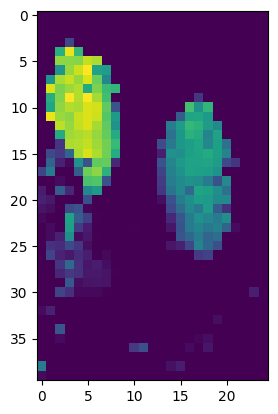

In [4]:
# Key part of the code for forming the rules

eg = 2

X = []
for i in range(len(img_data[eg])):
    for j in range(len(img_data[eg][0])):
        for k in range(int((img_data[eg][i][j])/50)):
            X += [[j+np.random.randn(1)[0]/5,i+np.random.randn(1)[0]/5]]
X = np.array(X)

plt.imshow(img_data[eg])

Number of estimated clusters: 2
Cluster centers:
 [[ 4.42647121  9.85602119]
 [16.74899292 15.98972988]]


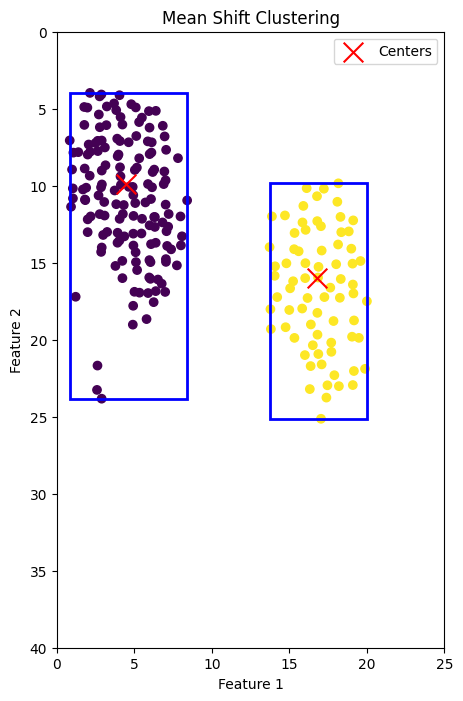

Bounding Boxes [left x, top y, right x, bottom y]:
Cluster 0: [0.83, 3.97, 8.4, 23.83]
Cluster 1: [13.72, 9.84, 20.0, 25.13]


In [5]:
# Bandwidth Estimation

# bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=len(X))
bandwidth = 6
min_cluster_size = 25

# Performing MeanShift
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)

# Finding the Cluster Centers
cluster_centers = ms.cluster_centers_
labels = ms.labels_

# Anomaly Removal
cluster_sizes = np.bincount(labels)
valid_clusters = cluster_sizes >= min_cluster_size
valid_cluster_centers = cluster_centers[valid_clusters]
filtered_labels = np.array([-1 if cluster_sizes[label] < min_cluster_size else label for label in labels])
X_filtered = X[filtered_labels != -1]
filtered_labels = filtered_labels[filtered_labels != -1]

# Finding the Number of Clusters
n_clusters_ = len(np.unique(filtered_labels))

# Print Cluster Centers
print(f"Number of estimated clusters: {n_clusters_}")
print("Cluster centers:\n", valid_cluster_centers)

# Visualization
plt.figure(figsize=(5, 8))
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=filtered_labels, cmap='viridis', marker='o')
plt.scatter(valid_cluster_centers[:, 0], valid_cluster_centers[:, 1], marker='x', color='red', s=200, label='Centers')

# Bounding Boxes
bounding_boxes = []
for label in np.unique(filtered_labels):
    cluster_points = X_filtered[filtered_labels == label]
    min_x, min_y = cluster_points.min(axis=0)
    max_x, max_y = cluster_points.max(axis=0)
    bounding_box = [np.round(min_x,2), np.round(min_y,2), np.round(max_x,2), np.round(max_y,2)]
    bounding_boxes.append(bounding_box)
    rect = plt.Rectangle((min_x, min_y), max_x - min_x, max_y - min_y, fill=False, edgecolor='blue', linewidth=2)
    plt.gca().add_patch(rect)

# Graph Settings
plt.xlim([0,25])
plt.ylim([0,40])
plt.title('Mean Shift Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.gca().invert_yaxis()
plt.show()

# Print Bounding Boxes
print("Bounding Boxes [left x, top y, right x, bottom y]:")
for i, bbox in enumerate(bounding_boxes):
    print(f"Cluster {i}: {bbox}")